In [49]:
import numpy as np
import matplotlib.pyplot as plt 

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline 
from sklearn.linear_model import LogisticRegression

In [51]:
#reproducibilidad 
SEED = 1234
rng = np.random.default_rng(SEED)

In [52]:
def awgn(x:np.ndarray, snr_db:float, rng_local = None)-> np.ndarray:
    """_summary_

    Args:
        x (np.ndarray): _description_
        snr_db (float): _description_
        rng_local (_type_, optional): _description_. Defaults to None.

     resp
        np.ndarray: _description_
    """
   
    if rng_local is None:
        rng_local = rng
        
    #Potencia promedio de la señal
    p_sig = np.mean(np.abs(x)**2)
    snr_lin = 10**(snr_db/10)
    
    #Potencia de ruido necesaria 
    p_noise = p_sig / snr_lin
    
    #Ruido complejo 
    noise = (rng_local.normal(0, np.sqrt(p_noise/2), size = x.shape) +
             1j * rng_local.normal(0, np.sqrt(p_noise/2), size = x.shape)) 
    
    return (x + noise).astype(np.complex64)

In [53]:
def rect_pulse_upsample(symbols:np.ndarray, sps:int) -> np.ndarray:
    """_summary_

    Args:
        symbols (np.ndarray): _description_
        sps (int): _description_

    UPSAMPLING con pulso rectangular, repite el simbolo "sps" veces
    Returns:
        np.ndarray: _description_
    """
    
    x = np.repeat(symbols, repeats = sps)
    return x.astype(np.complex64)
    


In [54]:
def iq_to_array(xc:np.ndarray) -> np.ndarray:
    """_
        Convierte una señal compleja en un array de dos columnas (I,Q)
    """
    
    return np.stack((xc.real, xc.imag), axis = -1).astype(np.float32)

In [55]:
def qam_symbols(nsym:int, M:int, rng_local=None)-> np.ndarray:
    """_summary_
    Genera símbolos M-QAM cuadrada(16 y 64), con energia media = 1.
    Array complejo de longitud nsym 
    """
    if rng_local is None:
        rng_local = rng
        
    m_side = int(np.sqrt(M))
    assert m_side * m_side == M  
    
    #indices 0 a M-1 
    idx = rng_local.integers(0, M, size = nsym)
    
    #indices en en eje I (columna) y Q (fila)
    i_idx = idx % m_side
    q_idx = idx // m_side
    
    # niveles en I y Q
    levels = np.arange(-(m_side -1), m_side, 2)
    
    I = levels[i_idx]
    Q = levels[q_idx]
    
    #Energía promedio para MQAM cuadrado = 2/3 *(M-1)
    Es = (2.0/3.0)*(M-1)
    scale = 1.0 / np.sqrt(Es)
    
    s = scale * (I + 1j * Q)
    return s.astype(np.complex64)


In [56]:
def make_clip_qam(order:int, T:int, sps:int, snr_db:float, rng_local=None)-> np.ndarray:
    """ 
    genera un clip de T muestras para M-QAM, filtrado rectangular  a sps muestras por simbolo 
    y con ruido AWGN. Retorna un vector complejo de longituf T.
    """
    
    if rng_local is None:
        rng_local = rng
        
    #numero de simbolos para cubrir T muestras
    nsym = int(np.ceil(T / sps))
    
    #simbolos QAM 
    syms = qam_symbols(nsym, order, rng_local)
    
    #upsampling con pulso rectangular
    x = rect_pulse_upsample(syms, sps)
    
    #recorte/ padding a T muestras 
    if len(x) < T:
        x = np.pad(x, (0, T - len(x)))
    else:
        x = x[:T]
        
    #añadir ruido AWGN
    xr = awgn(x, snr_db=snr_db, rng_local=rng_local)
    return xr 
    

In [57]:
#Parámetros globales 
SPS = 4 
T_list = [64,128,256,512,1024]
SNR_GRID = np.arange(5,26,5)#dB
N_PER_ORDER_SNR = 1500
ORDERS_QAM = [16,64]

In [58]:
print("len(ORDERS_QAM) =", len(ORDERS_QAM))
print("len(T_list)     =", len(T_list))
print("len(SNR_GRID)   =", len(SNR_GRID))
print("N_PER_ORDER_SNR =", N_PER_ORDER_SNR)

N_theoretical = len(ORDERS_QAM)*len(T_list)*len(SNR_GRID)*N_PER_ORDER_SNR
print("N_theoretical   =", N_theoretical)

# A PARTIR DE AQUÍ N_total_qam ES EXACTAMENTE EL TEÓRICO
N_total_qam = N_theoretical

T_max = max(T_list)
print("N_total_qam     =", N_total_qam)
print("T_max           =", T_max)

len(ORDERS_QAM) = 2
len(T_list)     = 5
len(SNR_GRID)   = 5
N_PER_ORDER_SNR = 1500
N_theoretical   = 75000
N_total_qam     = 75000
T_max           = 1024


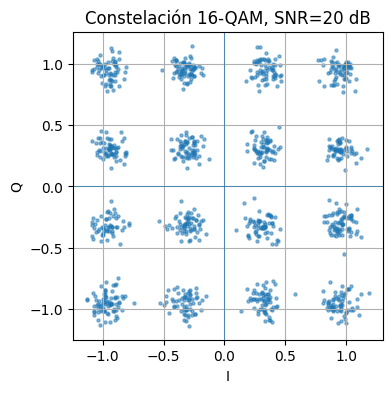

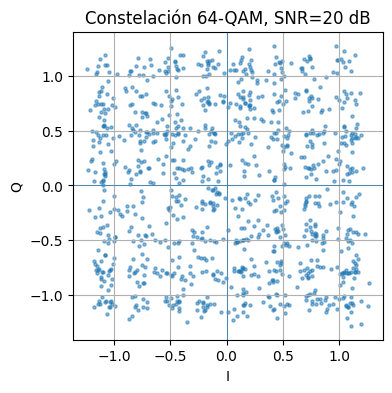

In [59]:

def plot_constellation(xc:np.ndarray, title: str=""):
    x_plot = xc[::SPS]  # tomar una muestra por símbolo
    plt.figure(figsize=(4, 4))
    plt.scatter(x_plot.real, x_plot.imag, s=5, alpha=0.5)
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.title(title)
    plt.grid(True)
    plt.show()

# %%
# Ejemplo 16-QAM
xc_16 = make_clip_qam(order=16, T=4096, sps=SPS, snr_db=20.0, rng_local=rng)
plot_constellation(xc_16, "Constelación 16-QAM, SNR=20 dB")

# Ejemplo 64-QAM
xc_64 = make_clip_qam(order=64, T=4096, sps=SPS, snr_db=20.0, rng_local=rng)
plot_constellation(xc_64, "Constelación 64-QAM, SNR=20 dB")

In [60]:
T_max =max(T_list)

N_total_qam = (
    len(ORDERS_QAM) * 
    len(SNR_GRID) * 
    N_PER_ORDER_SNR   
)

print(f"Número total de clips QAM a generar: {N_total_qam}")

Número total de clips QAM a generar: 15000


In [61]:
"""

# BORRAR arrays viejos si existen
for name in ["X_qam", "y_order_qam", "snr_qam", "T_used_qam"]:
    if name in globals():
        del globals()[name]

X_qam = np.empty((N_total_qam, T_max,2), dtype=np.float32)
y_order_qam = np.empty((N_total_qam,), dtype=np.int16)

snr_qam = np.empty((N_total_qam,), dtype=np.float32)
T_used_qam = np.empty(N_total_qam, dtype=np.int16)

""" 

'\n\n# BORRAR arrays viejos si existen\nfor name in ["X_qam", "y_order_qam", "snr_qam", "T_used_qam"]:\n    if name in globals():\n        del globals()[name]\n\nX_qam = np.empty((N_total_qam, T_max,2), dtype=np.float32)\ny_order_qam = np.empty((N_total_qam,), dtype=np.int16)\n\nsnr_qam = np.empty((N_total_qam,), dtype=np.float32)\nT_used_qam = np.empty(N_total_qam, dtype=np.int16)\n\n'

In [62]:
"""
print("x_qam existe? ->", 'x_qam' in globals())
print("X_qam existe? ->", 'X_qam' in globals())
if 'x_qam' in globals():
    print("x_qam.shape =", x_qam.shape)
if 'X_qam' in globals():
    print("X_qam.shape =", X_qam.shape)
print("N_total_qam =", N_total_qam)

"""


'\nprint("x_qam existe? ->", \'x_qam\' in globals())\nprint("X_qam existe? ->", \'X_qam\' in globals())\nif \'x_qam\' in globals():\n    print("x_qam.shape =", x_qam.shape)\nif \'X_qam\' in globals():\n    print("X_qam.shape =", X_qam.shape)\nprint("N_total_qam =", N_total_qam)\n\n'

In [63]:
# Construimos el dataset con listas (sin preasignar tamaño)
clips   = []
orders  = []
snrs    = []
Ts_used = []

T_max = max(T_list)   # lo necesitas igual para el padding

for T_ in T_list:
    print(f"Generando QAM para T = {T_}...")
    for order in ORDERS_QAM:
        for snr_db in SNR_GRID:
            for _ in range(N_PER_ORDER_SNR):
                xc = make_clip_qam(
                    order=order,
                    T=T_,
                    sps=SPS,
                    snr_db=float(snr_db),
                    rng_local=rng,
                )

                x_arr = iq_to_array(xc)          # (T_, 2)

                # Padding a T_max
                if T_ < T_max:
                    x_pad = np.zeros((T_max, 2), dtype=np.float32)
                    x_pad[:T_, :] = x_arr
                else:
                    x_pad = x_arr

                clips.append(x_pad)
                orders.append(order)
                snrs.append(snr_db)
                Ts_used.append(T_)

# Convertimos listas -> arrays
X_qam       = np.stack(clips, axis=0)           # (N_total, T_max, 2)
y_order_qam = np.array(orders, dtype=np.int16)
snr_qam     = np.array(snrs,   dtype=np.float32)
T_used_qam  = np.array(Ts_used, dtype=np.int16)

print("X_qam.shape =", X_qam.shape)
print("N_total_qam =", X_qam.shape[0])
print("órdenes únicos:", np.unique(y_order_qam))
print("SNR únicas    :", np.unique(snr_qam))
print("T únicos      :", np.unique(T_used_qam))



Generando QAM para T = 64...
Generando QAM para T = 128...
Generando QAM para T = 256...
Generando QAM para T = 512...
Generando QAM para T = 1024...
X_qam.shape = (75000, 1024, 2)
N_total_qam = 75000
órdenes únicos: [16 64]
SNR únicas    : [ 5. 10. 15. 20. 25.]
T únicos      : [  64  128  256  512 1024]


In [64]:
np.savez_compressed(
    "qam_dataset_multiT_multiSNR.npz",
    X=X_qam,
    order=y_order_qam,
    snr_db=snr_qam,
    T=T_used_qam,
)


In [74]:
"""
data = np.load("qam_dataset_multiT_multiSNR.npz")
X = data["X"]
order = data["order"]
snr_qam = data["snr_db"]
T_used_qam = data["T"]

"""

'\ndata = np.load("qam_dataset_multiT_multiSNR.npz")\nX = data["X"]\norder = data["order"]\nsnr_qam = data["snr_db"]\nT_used_qam = data["T"]\n\n'

In [75]:
"""
print("X.shape:", X.shape)
print("Ordenes:", np.unique(order))
print("T usados:", np.unique(T_used_qam))
"""

'\nprint("X.shape:", X.shape)\nprint("Ordenes:", np.unique(order))\nprint("T usados:", np.unique(T_used_qam))\n'

In [76]:
import numpy as np

data = np.load("qam_dataset_multiT_multiSNR.npz")
X      = data["X"]
order  = data["order"]
snr_db = data["snr_db"]
T_used = data["T"]

T_max = X.shape[1]
mask = (T_used == T_max) & (snr_db >= 10.0)  # solo SNR >= 10 dB

Xb = X[mask]
yb = order[mask]

y_bin = (yb == 64).astype(int)
N, T_max, _ = Xb.shape
X_flat = Xb.reshape(N, -1)


In [77]:
"""
T_max = X.shape[1]
mask = (T_used_qam == T_max)

Xb = X[mask]
yb = order[mask]

print("Xb:", Xb.shape)
"""

'\nT_max = X.shape[1]\nmask = (T_used_qam == T_max)\n\nXb = X[mask]\nyb = order[mask]\n\nprint("Xb:", Xb.shape)\n'

In [68]:
"""
y_bin = (yb == 64).astype(int)

"""

In [78]:
"""
N, T_max, _ = Xb.shape
X_flat = Xb.reshape(N, -1)
print("X_flat shape:", X_flat.shape)
"""

'\nN, T_max, _ = Xb.shape\nX_flat = Xb.reshape(N, -1)\nprint("X_flat shape:", X_flat.shape)\n'

In [82]:
"""
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)
"""

'\nX_train, X_test, y_train, y_test = train_test_split(\n    X_flat, y_bin,\n    test_size=0.2,\n    random_state=42,\n    stratify=y_bin\n)\n'

In [83]:
"""
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

clf.fit(X_train, y_train)
"""

'\nclf = make_pipeline(\n    StandardScaler(),\n    LogisticRegression(max_iter=2000)\n)\n\nclf.fit(X_train, y_train)\n'

In [84]:
"""
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("=== Baseline: Logistic Regression ===")
print(classification_report(y_test, y_pred, target_names=["16QAM", "64QAM"]))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

"""


'\nfrom sklearn.metrics import classification_report, confusion_matrix\n\ny_pred = clf.predict(X_test)\n\nprint("=== Baseline: Logistic Regression ===")\nprint(classification_report(y_test, y_pred, target_names=["16QAM", "64QAM"]))\n\nprint("Matriz de confusión:")\nprint(confusion_matrix(y_test, y_pred))\n\n'

In [85]:
def clip_to_complex(x_clip):
    """x_clip: (T, 2) -> z: (T,) complejo."""
    return x_clip[:, 0] + 1j * x_clip[:, 1]

def normalize_power(z):
    """Quita media y normaliza a potencia unitaria."""
    z = z - np.mean(z)
    p = np.mean(np.abs(z)**2) + 1e-12
    return z / np.sqrt(p)


In [86]:
def cumulant_features(z):
    """
    z: señal compleja 1D
    Devuelve vector de features basado en momentos/cumulantes de 2º y 4º orden.
    """
    z = normalize_power(z)

    # Momentos
    m20 = np.mean(z**2)
    m21 = np.mean(np.abs(z)**2)
    m40 = np.mean(z**4)
    m41 = np.mean((z**3) * np.conj(z))
    m42 = np.mean((z**2) * (np.conj(z)**2))

    # Cumulantes (ver literatura AMC clásica)
    c20 = m20
    c21 = m21
    c40 = m40 - 3 * (m20**2)
    c41 = m41 - 3 * m20 * m21
    c42 = m42 - np.abs(m20)**2 - 2 * (m21**2)

    feats = np.array([
        np.real(c20), np.imag(c20),
        np.real(c21),                # potencia (real)
        np.real(c40), np.imag(c40),
        np.real(c41), np.imag(c41),
        np.real(c42), np.imag(c42),
    ], dtype=np.float32)

    return feats


In [87]:
# Usamos otra vez sólo T_max y, si quieres, SNR >= 0 o >=10
T_max = X.shape[1]
mask = (T_used == T_max)  # opcionalmente & (snr_db >= 0)

Xb = X[mask]
yb = order[mask]
y_bin = (yb == 64).astype(int)

N = Xb.shape[0]
X_feat = np.empty((N, 9), dtype=np.float32)

for i in range(N):
    z = clip_to_complex(Xb[i])
    X_feat[i] = cumulant_features(z)

print("X_feat shape:", X_feat.shape)
print("Ejemplo de features para un clip:", X_feat[0])


X_feat shape: (15000, 9)
Ejemplo de features para un clip: [-3.4321140e-02  5.0824199e-02  1.0000000e+00 -3.1571057e-01
  2.6301236e-03  5.1426947e-02 -3.6929261e-02 -4.2929387e-01
  1.0831873e-09]


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

# Puedes probar los dos modelos:
log_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

mlp_clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 64),
                  activation="relu",
                  max_iter=200,
                  random_state=42)
)

print("Entrenando Logistic...")
log_clf.fit(X_train, y_train)

print("Entrenando MLP...")
mlp_clf.fit(X_train, y_train)

# Métricas
for name, clf in [("Logistic", log_clf), ("MLP", mlp_clf)]:
    y_pred = clf.predict(X_test)
    print(f"\n=== Baseline cumulantes: {name} ===")
    print(classification_report(
        y_test, y_pred,
        target_names=["16QAM", "64QAM"]
    ))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))


Entrenando Logistic...
Entrenando MLP...

=== Baseline cumulantes: Logistic ===
              precision    recall  f1-score   support

       16QAM       0.57      0.72      0.64      1500
       64QAM       0.62      0.47      0.54      1500

    accuracy                           0.59      3000
   macro avg       0.60      0.59      0.59      3000
weighted avg       0.60      0.59      0.59      3000

Matriz de confusión:
[[1073  427]
 [ 795  705]]

=== Baseline cumulantes: MLP ===
              precision    recall  f1-score   support

       16QAM       0.75      0.73      0.74      1500
       64QAM       0.74      0.76      0.75      1500

    accuracy                           0.74      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.74      0.74      3000

Matriz de confusión:
[[1088  412]
 [ 354 1146]]


/home/lcmj2803/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
